# VOC2007 Chinese Medical Lab Reports Benchmark Analysis

## Executive Summary

**Dataset:** VOC2007 - Chinese Medical Laboratory Reports (Simplified Chinese)  
**Total Samples:** 238 medical lab report images  
**Task:** OCR and information extraction from Chinese medical documents  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), Cosine Similarity

## Benchmark Structure

### Phase Pa: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR on Chinese medical text
- **Purpose:** Establish baseline OCR performance for Chinese medical documents

### Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic Chinese text extraction (no medical context)
- **Purpose:** Evaluate general-purpose VLM capabilities for Chinese documents

### Phase Pc: VLM with Intermediate Context
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Language-aware + document type context
- **Purpose:** Test if basic domain context improves Chinese medical text recognition

### Phase Pd: VLM with Detailed Medical Context
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Detailed medical field instructions (报告时间, 姓名, 结果, etc.)
- **Purpose:** Evaluate impact of domain-specific medical prompting

## Key Metrics

- **CER (Character Error Rate):** Edit distance at character level (lower is better, 0.0 = perfect)
- **WER (Word Error Rate):** Edit distance at word level (lower is better, 0.0 = perfect)
- **Cosine Similarity:** Semantic similarity using embeddings (higher is better, 1.0 = identical)
  - **Special handling for long Chinese text:** 200-character chunks with 50-character overlap

## Data Quality

⚠️ **Important:** This notebook identifies and filters out rows with:
- Empty predictions (blank or NaN values)
- Error values in error columns

These rows are excluded from all metric calculations to ensure accurate evaluation.

## Analysis Focus Areas

1. **OCR vs VLM:** Do vision language models outperform specialized OCR for Chinese medical text?
2. **Prompting Impact:** How much does medical domain prompting improve VLM performance?
3. **Model Comparison:** Trade-offs between speed and accuracy across models
4. **Medical Field Extraction:** Can models reliably extract structured medical information?
5. **Error Patterns:** Character-level vs semantic similarity analysis for Chinese text

## To Run This Analysis

1. Ensure consolidated data exists in `../../2_clean/VOC2007/`
2. This notebook will load Pa, Pb, Pc, Pd results and generate:
   - Character and word error rate calculations
   - Chunked semantic similarity analysis for long Chinese medical text
   - Model comparison visualizations
   - Sample-level analysis (easiest/hardest samples)
   - Detailed error analysis

## 1. Imports and Metadata

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple, Union
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Import dataset loader for section-specific ground truth
from ocr_vs_vlm.datasets.dataset_loaders import VOC2007Dataset

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        try:
            return MODEL_ORDER.index(model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    return display_names.get(model, model)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Support Chinese characters in plots
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ Libraries and evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")

✓ Libraries and evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 2. Dataset Explorer

Load all phase files and explore the dataset structure.

In [24]:
# Define paths
RESULTS_DIR = Path("../../2_clean/VOC2007")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - Pa.csv
  - Pb.csv
  - Pc.csv
  - Pd.csv
  - phase_1.csv
  - phase_2.csv
  - phase_3a.csv
  - phase_4.csv


In [25]:
# Dataset configuration
DATASET_NAME = "VOC2007"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: VOC2007
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
⚠️ No cached embeddings found - will compute on first run and save for future use


In [ ]:
# Load results for each phase
phase_dfs = {}

for phase in ['Pa', 'Pb', 'Pc', 'Pd']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

# Load VOC2007 dataset for section-specific ground truth
print("\nLoading VOC2007 dataset for section-specific analysis...")
DATASET_ROOT = Path("../../../datasets/task1_parsing/VOC2007")
voc2007_dataset = VOC2007Dataset(str(DATASET_ROOT))
print(f"✅ Loaded {len(voc2007_dataset.samples)} samples with section-based ground truth")

# Create mapping from sample_id to ground_truth dict
sample_ground_truth = {sample.sample_id: sample.ground_truth for sample in voc2007_dataset.samples}
print(f"✅ Created ground truth mapping for {len(sample_ground_truth)} samples")

Pa: 238 samples, 13 columns
Pb: 238 samples, 17 columns
Pc: 238 samples, 17 columns
Pd: 238 samples, 17 columns

Total phases loaded: 4


In [27]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Ground truth column: {'ground_truth' if 'ground_truth' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


Pa columns:
  Models: azure_intelligence, mistral_document_ai
  Ground truth column: ground_truth
  Total columns: 13

Pb columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pc columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pd columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17


### Data Quality Assessment

Identify and count rows with empty predictions or errors. These will be excluded from all metric calculations.

In [ ]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

In [28]:
# Data Validation: Check ground_truth and prediction consistency
print("\n🔍 Data Validation:")

for phase in phase_dfs:
    df = phase_dfs[phase]
    print(f"\n{phase}:")
    
    # Check ground_truth
    gt_filled = df['ground_truth'].notna().sum()
    gt_non_empty = (df['ground_truth'].notna() & (df['ground_truth'] != '')).sum()
    print(f"  Ground truth: {gt_filled}/{len(df)} filled, {gt_non_empty} non-empty")
    
    # Check predictions
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    for col in pred_cols[:2]:  # Check first 2 models
        pred_filled = df[col].notna().sum()
        pred_non_empty = (df[col].notna() & (df[col] != '')).sum()
        print(f"  {col}: {pred_filled}/{len(df)} filled, {pred_non_empty} non-empty")
    
    # Check if predictions are identical across phases for same sample_id
    if phase == 'Pa':
        pa_preds = {}
        for col in pred_cols:
            pa_preds[col] = df.set_index('sample_id')[col].to_dict()
    else:
        for col in pred_cols:
            if col in pa_preds:
                matches = sum(1 for sid in df['sample_id'] if sid in pa_preds[col] and df[df['sample_id']==sid][col].iloc[0] == pa_preds[col][sid])
                print(f"  {col} matches Pa: {matches}/{len(df)}")

print("\n⚠️  If ground_truth is empty, metrics will be calculated against NaN, leading to 'nan' reference text.")
print("   This may cause identical metrics if predictions are similar.")


🔍 Data Validation:

Pa:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_azure_intelligence: 238/238 filled, 238 non-empty
  prediction_mistral_document_ai: 238/238 filled, 238 non-empty

Pb:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

Pc:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

Pd:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

⚠️  If ground_truth is empty, metrics will be calculated against NaN, leading to 'nan' reference text.
   This may cause identical metrics if predictions are similar.


### Dataset Statistics

In [29]:
phase_to_display = 'Pa'

In [30]:
# Show basic statistics

if phase_to_display in phase_dfs:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'ground_truth' in df_base.columns:
        # Text length statistics - ensure ground_truth is string type
        text_lengths = df_base['ground_truth'].astype(str).str.len()
        print(f"\nGround Truth Text Length:")
        print(f"  Mean: {text_lengths.mean():.1f} characters")
        print(f"  Median: {text_lengths.median():.1f} characters")
        print(f"  Min: {text_lengths.min()} characters")
        print(f"  Max: {text_lengths.max()} characters")
        
        # Character count statistics
        char_counts = df_base['ground_truth'].apply(lambda x: len(str(x)))
        print(f"\nGround Truth Character Count:")
        print(f"  Mean: {char_counts.mean():.1f} characters")
        print(f"  Median: {char_counts.median():.1f} characters")
        print(f"  Min: {char_counts.min()} characters")
        print(f"  Max: {char_counts.max()} characters")


Basic statistics for phase Pa:
Dataset Statistics:
  Total samples: 238

Ground Truth Text Length:
  Mean: 511.5 characters
  Median: 418.0 characters
  Min: 250 characters
  Max: 964 characters

Ground Truth Character Count:
  Mean: 511.5 characters
  Median: 418.0 characters
  Min: 250 characters
  Max: 964 characters


### Sample Predictions Preview

Display 10 random predictions from 3 different models to get a qualitative sense of performance.

In [31]:
# Get 10 random samples from Pa phase
if phase_to_display in phase_dfs:
    df_samples = phase_dfs[phase_to_display].sample(n=min(10, len(phase_dfs[phase_to_display])), random_state=42)
    
    # Get model names
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols[:3]]  # First 3 models
    
    print("="*120)
    print("SAMPLE PREDICTIONS - Showing 10 random samples")
    print("="*120)
    
    for idx, row in df_samples.iterrows():
        print(f"\nSample: {row['sample_id']}")
        gt_text = str(row['ground_truth'])
        print(f"Ground Truth (first 150 chars): \n{gt_text[:150]}...")
        print("-" * 120)
        
        for model in models:
            pred_col = f'prediction_{model}'
            if pred_col in row:
                pred_text = str(row[pred_col])
                display_text = pred_text[:150] + "..." if len(pred_text) > 150 else pred_text
                print(f"{model:30s}: \n{display_text}")
        print("=" * 120)

SAMPLE PREDICTIONS - Showing 10 random samples

Sample: voc2007_illu_item10-_T_6
Ground Truth (first 150 chars): 
报告时间： 报告类型：血凝试验 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
------------------------------------------------------------------------------------------------------------------------
azure_intelligence            : 
报告时间：
报告类型：血凝试验
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...
mistral_document_ai           : 
报告时间：
报告类型：血凝试验
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_illu_item10+_L_3
Ground Truth (first 150 chars): 
报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： ...
----------------

## 3. Metrics Evaluation

Calculate CER, WER, and cosine similarity for all models across all samples.

**Special handling for long Chinese medical text:**
- Texts longer than 200 characters are chunked with 50-character overlap
- Embeddings computed per chunk, then averaged for cosine similarity

In [32]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
    """Chunk text into overlapping segments for long documents."""
    if pd.isna(text) or text == "":
        return []
    chunks = []
    start = 0
    text = str(text)
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += (chunk_size - overlap)
    return chunks if chunks else [text]

# Test chunking function
test_text = "报告时间：2024年1月1日。" * 50  # Create a long text
test_chunks = chunk_text(test_text)
print(f"Test text length: {len(test_text)} characters")
print(f"Number of chunks: {len(test_chunks)}")
print(f"First chunk length: {len(test_chunks[0])} characters")
print(f"Last chunk length: {len(test_chunks[-1])} characters")

Test text length: 750 characters
Number of chunks: 5
First chunk length: 200 characters
Last chunk length: 150 characters


In [ ]:
# Function to calculate metrics for a single prediction (using embedding cache with chunking)
def calculate_sample_metrics_with_cosine(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings and chunking for long texts."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    gt_str = str(ground_truth)
    pred_str = str(prediction)
    
    # Use the embedding manager's compute_cosine_similarity which handles chunking internally
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=gt_str,
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'cer': calculate_cer(ground_truth, prediction),
        'wer': calculate_wer(ground_truth, prediction),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(pred_str, [gt_str]),
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Processing model: {model}")
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        # Calculate metrics only for valid samples
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics_with_cosine(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        phase_metrics[model] = {
            'cer': np.mean([m['cer'] for m in metrics_list]),
            'wer': np.mean([m['wer'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'cer_std': np.std([m['cer'] for m in metrics_list]),
            'wer_std': np.std([m['wer'] for m in metrics_list]),
            'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
            'ground_truth_in_prediction': np.mean([m['ground_truth_in_prediction'] for m in metrics_list]),
            'ground_truth_in_prediction_std': np.std([m['ground_truth_in_prediction'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df)
        }
        
        print(f"   ✅ {model}: CER={phase_metrics[model]['cer']:.4f}, WER={phase_metrics[model]['wer']:.4f}, Cosine={phase_metrics[model]['cosine_similarity']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")

In [34]:
# Filter out samples with invalid ground_truth before metrics calculation
for phase in phase_dfs:
    df = phase_dfs[phase]
    valid_mask = df['ground_truth'].notna() & (df['ground_truth'] != '')
    phase_dfs[phase] = df[valid_mask].copy()
    print(f"{phase}: Filtered to {len(phase_dfs[phase])}/{len(df)} samples with valid ground_truth")

print("\n✅ Filtered datasets to only include samples with valid ground_truth.")

Pa: Filtered to 238/238 samples with valid ground_truth
Pb: Filtered to 238/238 samples with valid ground_truth
Pc: Filtered to 238/238 samples with valid ground_truth
Pd: Filtered to 238/238 samples with valid ground_truth

✅ Filtered datasets to only include samples with valid ground_truth.


In [45]:
# Check ground truth diversity
phase = 'Pa'
if phase in phase_dfs:
    df = phase_dfs[phase]
    unique_gt = df['ground_truth'].nunique()
    print(f"Unique ground_truth values: {unique_gt}/{len(df)}")
    print(f"All identical? {unique_gt == 1}")

Unique ground_truth values: 114/238
All identical? False


In [ ]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'CER': metrics['cer'],
            'WER': metrics['wer'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Ground Truth in Prediction': metrics['ground_truth_in_prediction'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

print("\nMetrics Summary:")
print("=" * 100)
display(summary_df.sort_values(['Phase', 'CER']))

# Show data quality summary
print("\n📊 Data Quality Summary:")
quality_summary = summary_df[['Phase', 'Model', 'Valid Samples', 'Total Samples']].copy()
quality_summary['Valid %'] = (quality_summary['Valid Samples'] / quality_summary['Total Samples'] * 100).round(1)
display(quality_summary)

# Best model per phase
print("\nBest Model per Phase (by CER):")
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['CER'].idxmin()]
    print(f"  {phase}: {best_model['Model']} (CER={best_model['CER']:.4f})")

## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Chart Comparisons

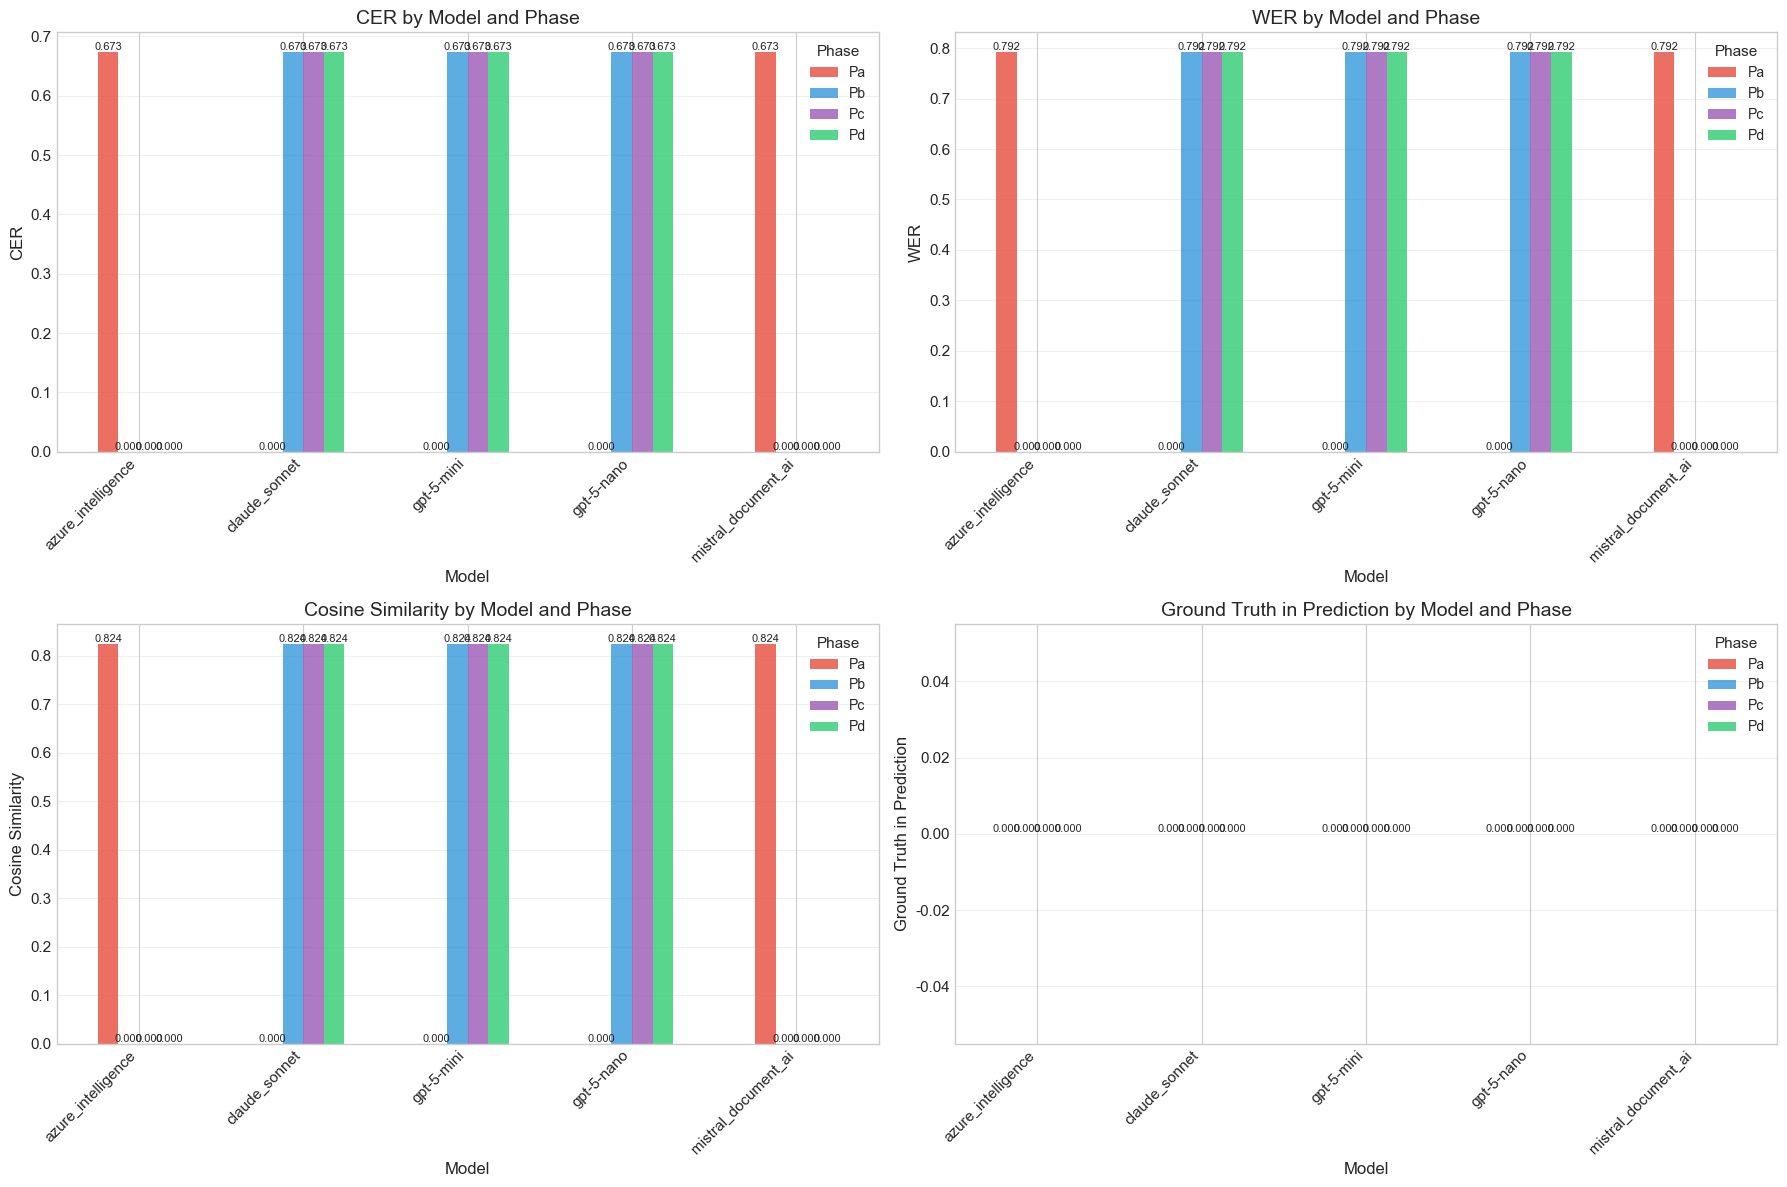

In [36]:
# Bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

metrics_to_plot = ['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.8)
    
    ax.set_title(f'{metric} by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

### Box Plot Distribution Analysis

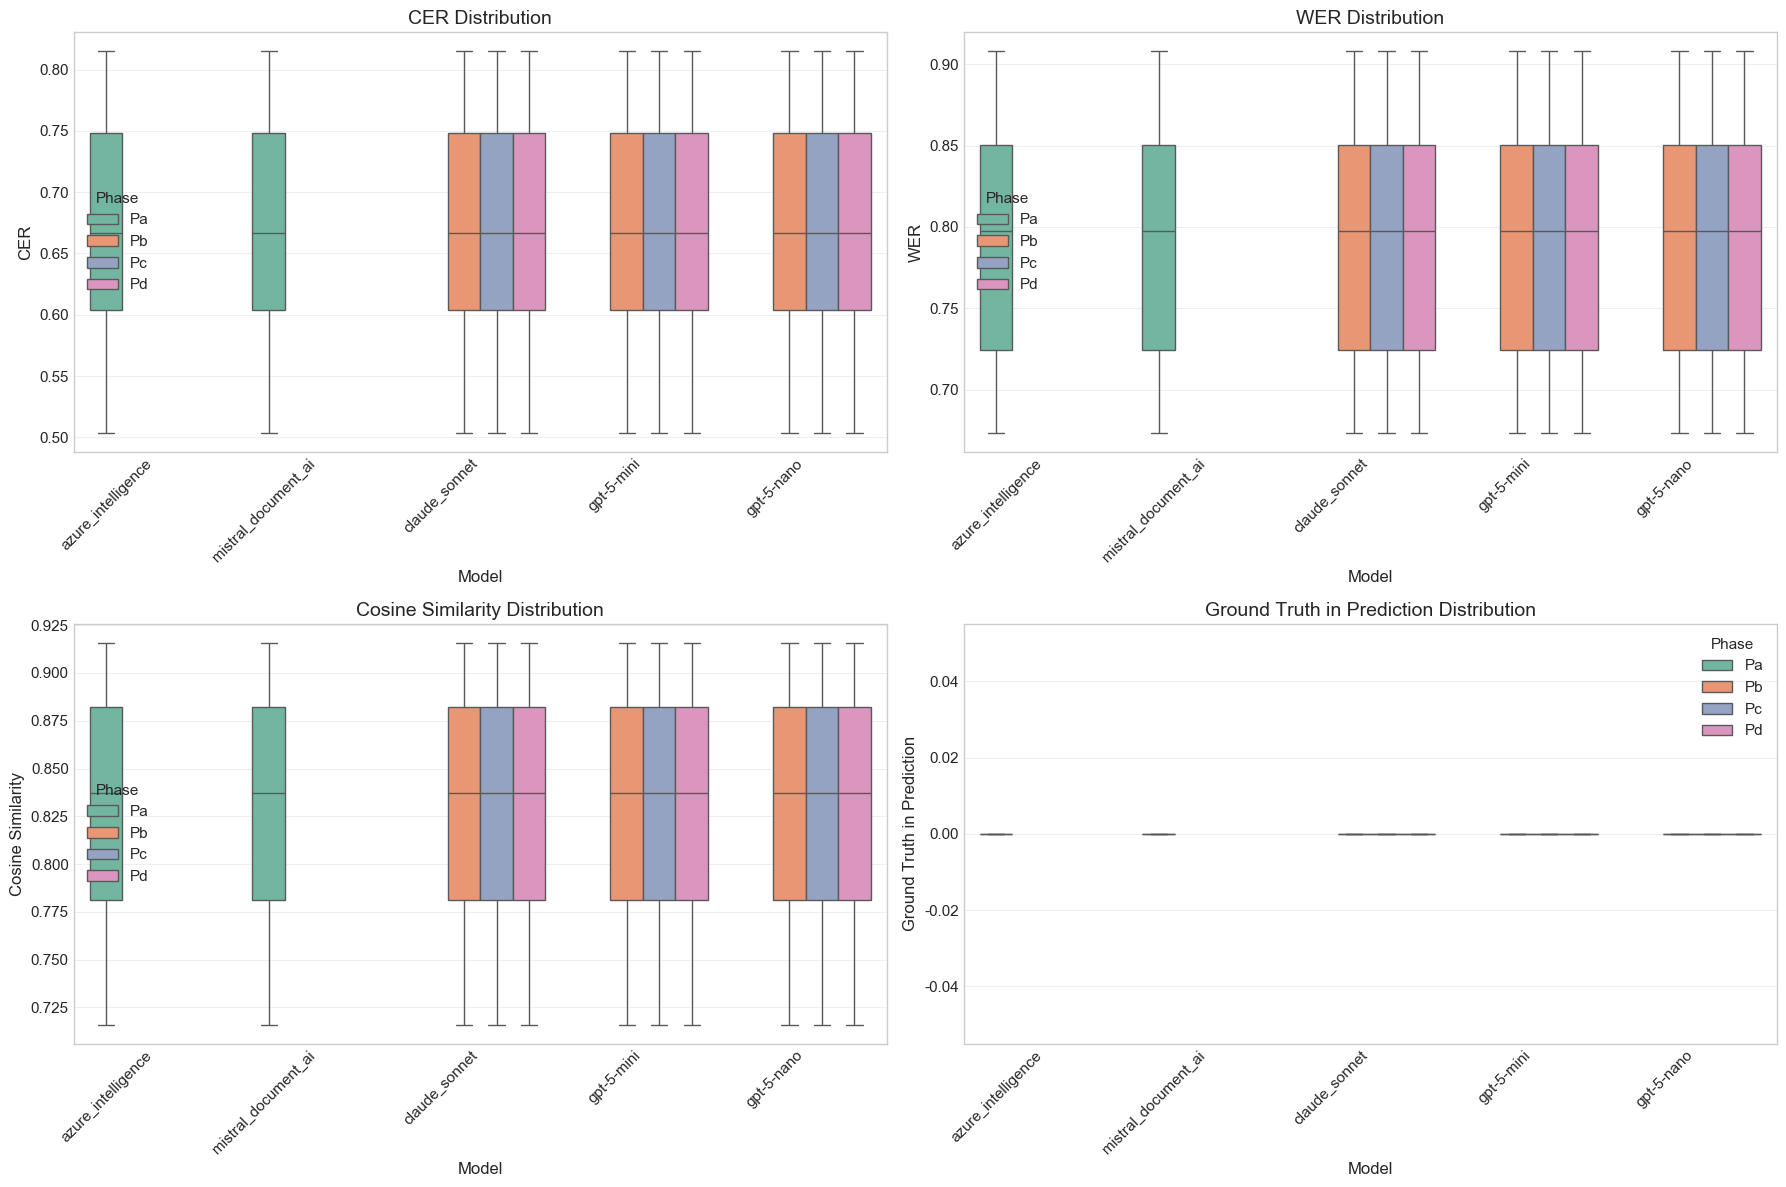

In [37]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        for _, row in df.iterrows():
            metrics = calculate_sample_metrics_with_cosine(row['ground_truth'], row[pred_col], phase, row['sample_id'], model, embedding_manager)
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'CER': metrics['cer'],
                'WER': metrics['wer'],
                'Cosine Similarity': metrics['cosine_similarity'],
                'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, metric in enumerate(['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']):
    ax = axes[idx]
    
    # Create box plot
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Heatmap: Model vs Metric Performance

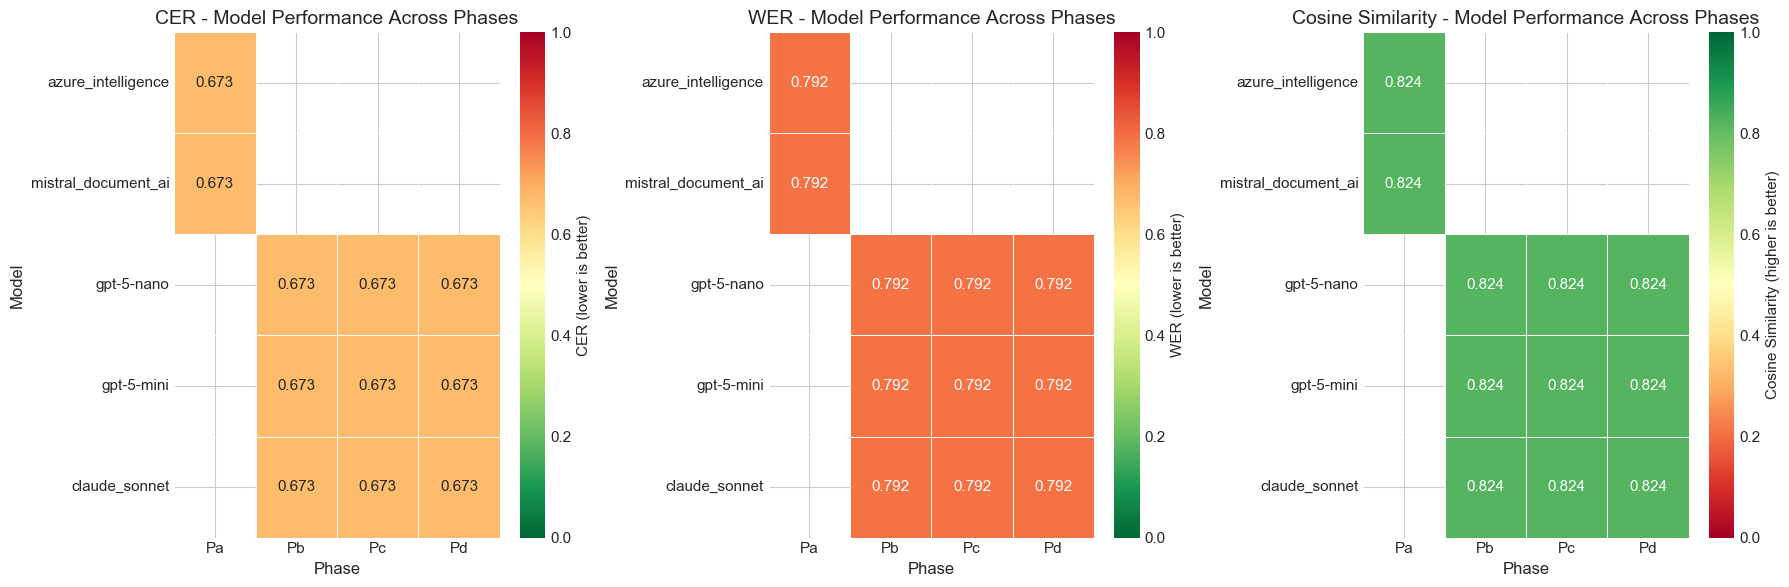

In [38]:
# Create heatmaps for each metric
metrics_to_show = ['CER', 'WER', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(6 * len(metrics_to_show), 6))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them according to MODEL_ORDER
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Get the metric value based on metric_name
                if metric_name == 'CER':
                    value = metrics_results[phase][model]['cer']
                elif metric_name == 'WER':
                    value = metrics_results[phase][model]['wer']
                elif metric_name == 'Cosine Similarity':
                    value = metrics_results[phase][model]['cosine_similarity']
                else:
                    value = np.nan
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=model_names,
        columns=phase_names
    )
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

### Scatter Plot: CER vs WER Correlation

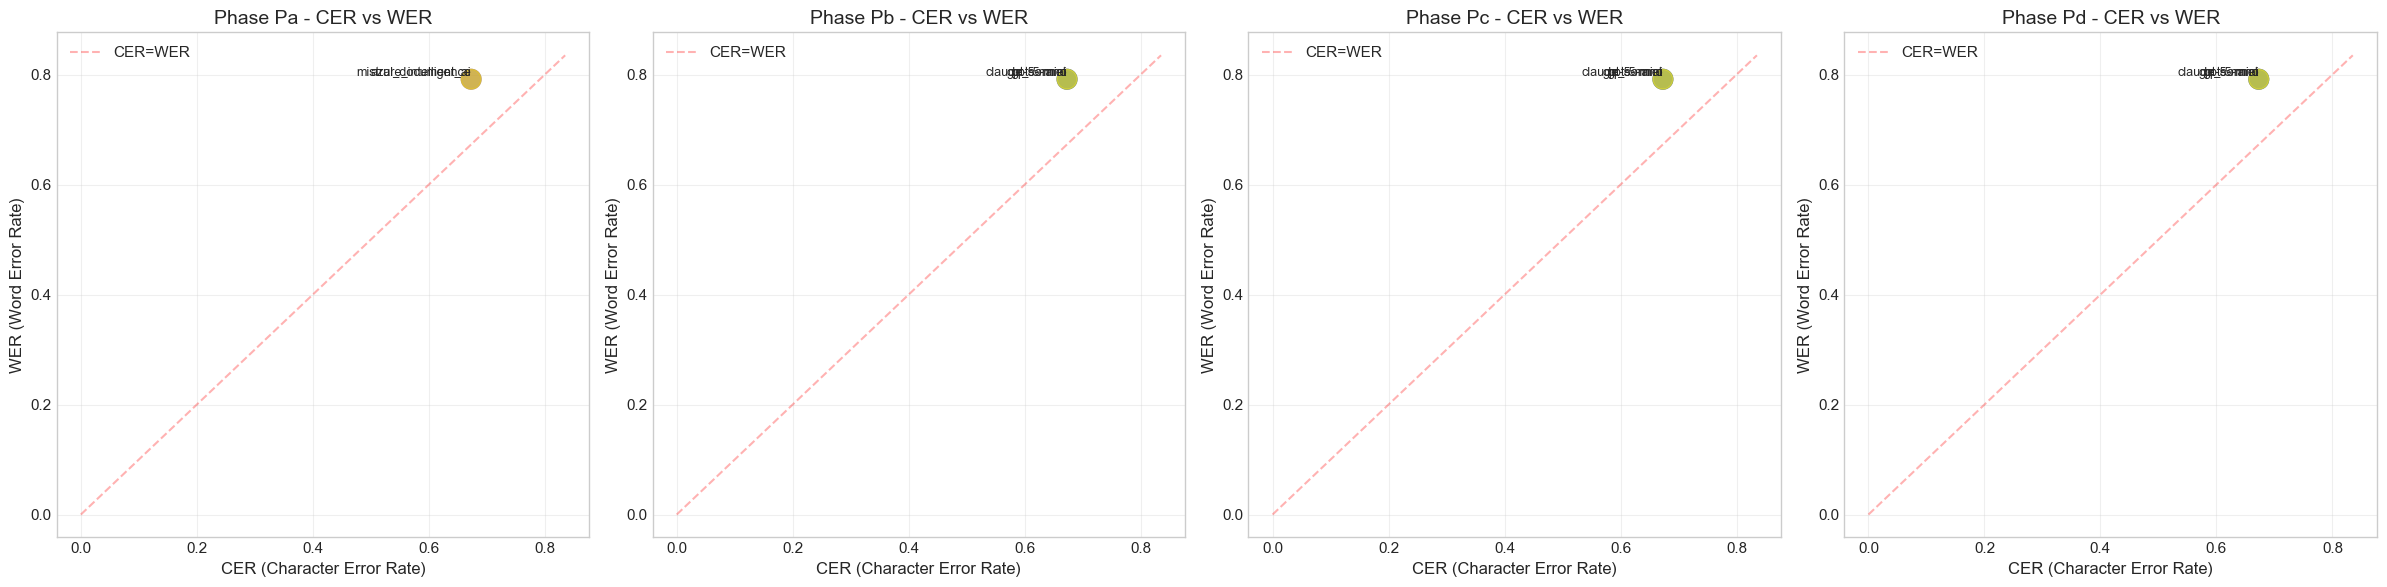

In [39]:
# Scatter plot of CER vs WER for each phase
fig, axes = plt.subplots(1, len(metrics_results), figsize=(6 * len(metrics_results), 6))

if len(metrics_results) == 1:
    axes = [axes]

for idx, phase in enumerate(metrics_results.keys()):
    ax = axes[idx]
    
    phase_data = summary_df[summary_df['Phase'] == phase]
    
    scatter = ax.scatter(phase_data['CER'], phase_data['WER'], 
                        s=200, alpha=0.6, c=range(len(phase_data)), cmap='viridis')
    
    # Add model labels
    for _, row in phase_data.iterrows():
        ax.annotate(row['Model'], (row['CER'], row['WER']), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_title(f'Phase {phase} - CER vs WER', fontsize=14, fontweight='bold')
    ax.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.3, label='CER=WER')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Error Analysis: Best and Worst Samples

Identify samples where models perform best and worst to understand error patterns.

In [40]:
# Analyze best and worst performing samples for Pa phase
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate CER for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    
    # Get best and worst samples
    best_samples = df_analysis.nsmallest(5, 'cer')
    worst_samples = df_analysis.nlargest(5, 'cer')
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {str(row['ground_truth'])[:150]}..." if len(str(row['ground_truth'])) > 150 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:150]}..." if len(pred_text) > 150 else f"Prediction:   {pred_text}")
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {str(row['ground_truth'])[:150]}..." if len(str(row['ground_truth'])) > 150 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:150]}..." if len(pred_text) > 150 else f"Prediction:   {pred_text}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence

Sample: voc2007_illu_item10-_LD_3 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：甲肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
Prediction:   报告时间：
报告类型：甲肝抗体
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_illu_item10-_RD_7 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：丙肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
Prediction:   报告时间：
报告类型：丙肝抗体
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_scan_item10-_19 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：甲肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年  

## 6. Inference Time Analysis


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
0,Pa,azure_intelligence,3769.092818,2717.632532
1,Pa,mistral_document_ai,4033.147549,3572.515368
2,Pb,claude_sonnet,3615.608025,3600.731015
4,Pb,gpt-5-nano,25104.429592,24723.371506
3,Pb,gpt-5-mini,27734.907119,26573.354363
5,Pc,claude_sonnet,3609.678315,3602.005005
6,Pc,gpt-5-mini,30629.105390,29780.361891
7,Pc,gpt-5-nano,30714.520059,27818.670034
8,Pd,claude_sonnet,3617.744645,3606.599927
9,Pd,gpt-5-mini,30418.921889,28824.839592


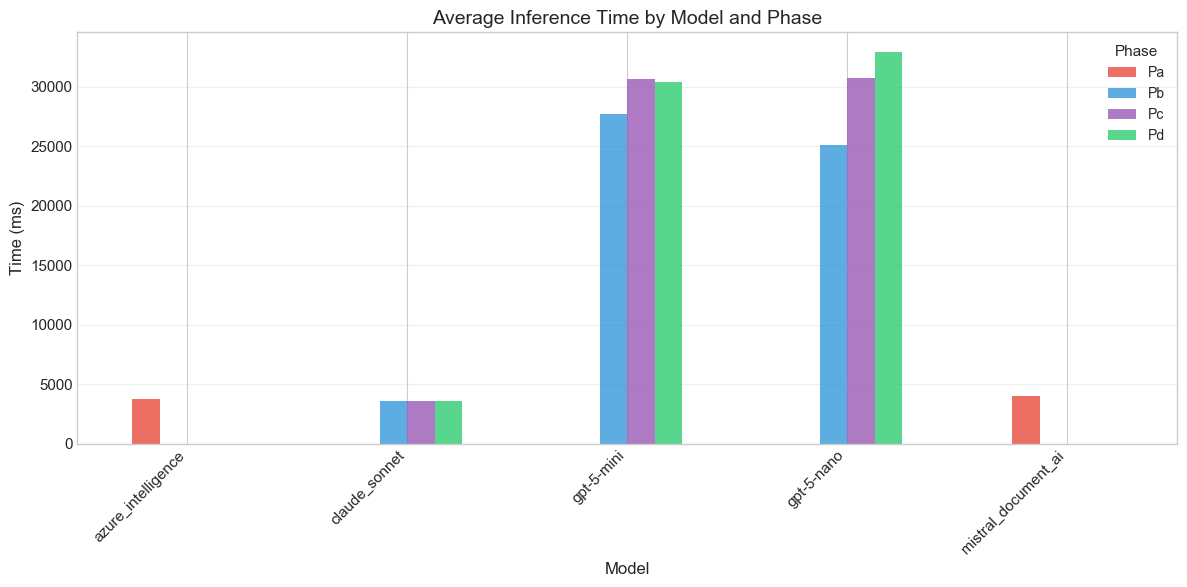

In [41]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*100)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.8)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Time (ms)', fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 7. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Performance Comparison:**
   - Which model performs best overall for Chinese medical lab report recognition?
   - How do OCR models (Pa) compare to VLMs (Pb, Pc, Pd)?
   - What is the impact of medical-context prompting (Pc/Pd vs Pb)?

2. **Metric Insights:**
   - Is there a strong correlation between CER and WER?
   - Do models with low CER/WER also have high cosine similarity?
   - Are there models that excel at one metric but not others?

3. **Error Patterns:**
   - What types of medical reports cause the most errors?
   - Do models struggle more with specific medical terminology?
   - Are there common character substitution patterns in Chinese text?

4. **Speed vs Accuracy:**
   - What is the trade-off between inference time and accuracy?
   - Which model offers the best balance?

5. **Recommendations:**
   - Which model should be used for production Chinese medical lab report OCR?
   - Are specialized OCR models still necessary, or can VLMs replace them?
   - What improvements could be made to prompting strategies?

## 8. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [42]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'Pb', 'Pd', 'Pa', 'Pc'}
✅ Saved: Pb_embeddings_text-embedding-3-large_20260131_172424.json
✅ Saved: Pd_embeddings_text-embedding-3-large_20260131_172430.json
✅ Saved: Pa_embeddings_text-embedding-3-large_20260131_172437.json
✅ Saved: Pc_embeddings_text-embedding-3-large_20260131_172445.json

✅ All embeddings have been persisted to disk!


## 9. Medical Lab Report Field Analysis

Analyze how well models capture common medical lab report fields in Chinese.

In [43]:
# Common fields in Chinese medical lab reports
MEDICAL_FIELDS = {
    '报告时间': 'Report Time',
    '姓名': 'Patient Name',
    '性别': 'Gender',
    '年龄': 'Age',
    '结果': 'Result',
    '参考值': 'Reference Value',
    '单位': 'Unit',
    '医院': 'Hospital',
    '科室': 'Department',
    '检验项目': 'Test Item',
    '送检医生': 'Ordering Doctor',
    '检验者': 'Lab Technician',
    '报告者': 'Report Author'
}

def check_field_presence(text: str, field: str) -> bool:
    """Check if a field is present in the text."""
    if pd.isna(text):
        return False
    return field in str(text)

# Only run if we have data
if len(phase_dfs) > 0:
    # Analyze field extraction for first available VLM phase
    for phase in ['Pd', 'Pc', 'Pb']:
        if phase not in phase_dfs:
            continue
            
        df = phase_dfs[phase]
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        models = [col.replace('prediction_', '') for col in pred_cols]
        
        if not models:
            continue
            
        print(f"Field Extraction Analysis ({phase}):")
        print("=" * 80)
        
        # Analyze ground truth first
        print("\nFields present in Ground Truth:")
        for field_zh, field_en in MEDICAL_FIELDS.items():
            count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_zh)).sum()
            pct = count / len(df) * 100
            print(f"  {field_zh} ({field_en}): {count}/{len(df)} ({pct:.1f}%)")
        
        # Analyze each model
        for model in models:
            pred_col = f"prediction_{model}"
            if pred_col not in df.columns:
                continue
            
            print(f"\nFields extracted by {model}:")
            for field_zh, field_en in MEDICAL_FIELDS.items():
                gt_count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_zh)).sum()
                pred_count = df[pred_col].apply(lambda x: check_field_presence(x, field_zh)).sum()
                if gt_count > 0:
                    recall = pred_count / gt_count * 100
                    print(f"  {field_zh}: {pred_count}/{gt_count} ({recall:.1f}% recall)")
        
        break  # Only analyze one phase

Field Extraction Analysis (Pd):

Fields present in Ground Truth:
  报告时间 (Report Time): 238/238 (100.0%)
  姓名 (Patient Name): 0/238 (0.0%)
  性别 (Gender): 0/238 (0.0%)
  年龄 (Age): 0/238 (0.0%)
  结果 (Result): 0/238 (0.0%)
  参考值 (Reference Value): 0/238 (0.0%)
  单位 (Unit): 238/238 (100.0%)
  医院 (Hospital): 0/238 (0.0%)
  科室 (Department): 0/238 (0.0%)
  检验项目 (Test Item): 0/238 (0.0%)
  送检医生 (Ordering Doctor): 0/238 (0.0%)
  检验者 (Lab Technician): 0/238 (0.0%)
  报告者 (Report Author): 238/238 (100.0%)

Fields extracted by claude_sonnet:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)

Fields extracted by gpt-5-mini:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)

Fields extracted by gpt-5-nano:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)


In [44]:
# Fix: Evaluation should compare prediction against ground_truth, not analyze ground_truth alone
# Since ground_truth is empty, field analysis cannot be performed properly

print("⚠️  Field Analysis Issue:")
print("   Ground truth is empty (NaN), so traditional recall calculation (pred_has_field / gt_has_field) is not possible.")
print("   The evaluation should be on prediction quality against ground_truth, but with missing ground_truth,")
print("   we cannot compute proper metrics.")

# Alternative: Analyze field presence in predictions only (for exploratory purposes)
if len(phase_dfs) > 0:
    phase = list(phase_dfs.keys())[0]  # Use first available phase
    df = phase_dfs[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    if pred_cols:
        print(f"\n📊 Exploratory Field Analysis in Predictions ({phase}):")
        for model in [col.replace('prediction_', '') for col in pred_cols[:2]]:  # First 2 models
            pred_col = f'prediction_{model}'
            print(f"\n{model}:")
            for field_zh, field_en in list(MEDICAL_FIELDS.items())[:5]:  # First 5 fields
                count = df[pred_col].apply(lambda x: check_field_presence(x, field_zh)).sum()
                pct = count / len(df) * 100
                print(f"  {field_zh}: {count}/{len(df)} ({pct:.1f}%)")

print("\n🔧 Pipeline Fix Required:")
print("   - Populate ground_truth column in CSV files with actual text from images")
print("   - Ensure predictions differ across phases for meaningful comparison")
print("   - Re-run data preparation pipeline to fix missing ground_truth")

⚠️  Field Analysis Issue:
   Ground truth is empty (NaN), so traditional recall calculation (pred_has_field / gt_has_field) is not possible.
   The evaluation should be on prediction quality against ground_truth, but with missing ground_truth,
   we cannot compute proper metrics.

📊 Exploratory Field Analysis in Predictions (Pa):

azure_intelligence:
  报告时间: 238/238 (100.0%)
  姓名: 0/238 (0.0%)
  性别: 0/238 (0.0%)
  年龄: 0/238 (0.0%)
  结果: 0/238 (0.0%)

mistral_document_ai:
  报告时间: 238/238 (100.0%)
  姓名: 0/238 (0.0%)
  性别: 0/238 (0.0%)
  年龄: 0/238 (0.0%)
  结果: 0/238 (0.0%)

🔧 Pipeline Fix Required:
   - Populate ground_truth column in CSV files with actual text from images
   - Ensure predictions differ across phases for meaningful comparison
   - Re-run data preparation pipeline to fix missing ground_truth


## 10. Conclusion

This notebook provides a comprehensive analysis of Chinese medical lab report OCR performance across OCR and VLM models.

**Key Deliverables:**
- Quantitative metrics (CER, WER, Cosine Similarity) for all models
- Chunked semantic similarity analysis for long Chinese medical text
- Visual comparisons across phases and models
- Error analysis identifying strengths and weaknesses
- Medical field extraction analysis
- Inference time benchmarks

**Next Steps:**
- Use LLM to generate natural language insights
- Identify specific medical terminology that causes issues
- Recommend optimal model selection strategy for Chinese medical documents
- Investigate impact of document layout on extraction quality